## Import and Read Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

zipcode_data = pd.read_csv('telecom_zipcode_population.csv')
customer_data = pd.read_csv('telecom_customer_churn.csv')

customer_data.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## Kaplan Meier Curve

### Overall Survival Curve

Text(0.5, 1.0, 'Overall Kaplan-Meier Survival Function')

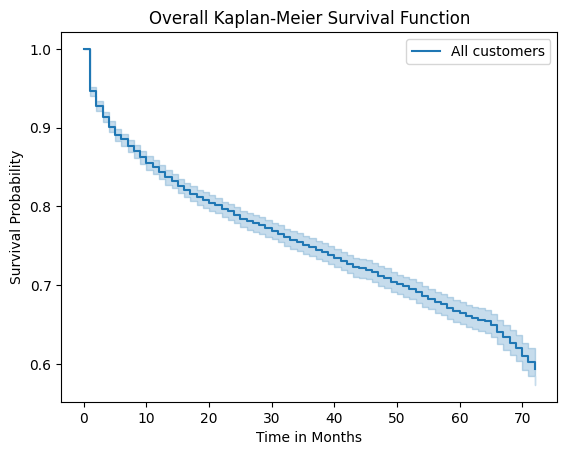

In [2]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

T = customer_data['Tenure in Months']
E = (customer_data['Customer Status'] == 'Churned').astype(int)
# astype(int) classifies Churned as 1 and all others as 0

kmf.fit(durations = T,
        event_observed = E,
        label= 'All customers')

kmf.plot_survival_function()
plt.xlabel('Time in Months')
plt.ylabel('Survival Probability')
plt.title('Overall Kaplan-Meier Survival Function')

We can expect more than half of all customers to remain past 70 months

### Survival Curve by Contract Type

During our XGBoost analysis, we saw that contract type was ranked as a highly significant variable in predicting churn. Below, we visualise what customer survival looks like per contract type

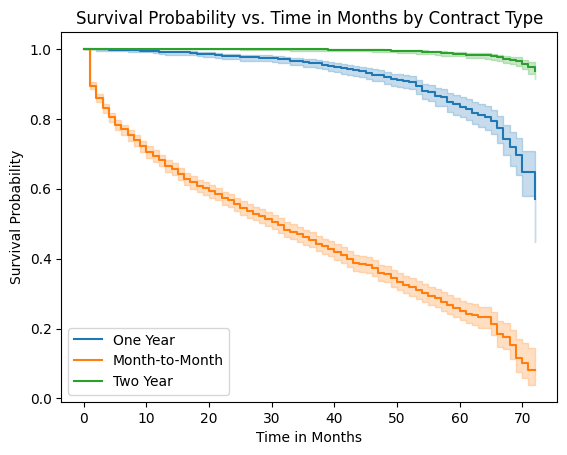

In [3]:
for contract_type in customer_data['Contract'].unique():
    mask = customer_data['Contract'] == contract_type
    kmf.fit(durations = T[mask],
            event_observed = E[mask],
            label = contract_type)

    kmf.plot_survival_function()
    plt.xlabel('Time in Months')
    plt.ylabel('Survival Probability')
    plt.title('Survival Probability vs. Time in Months by Contract Type')

Unsurprisingly, longer contracts see the highest customer survival over time.

It is unclear from the data source whether these contracts are lock-in. Assuming that they are, Contract would be considered a structural barrier to churn rather than a predictor. Later, we will address this.

### Survival Curve by Monthly Charges

*Note: KM curves cannot be constructed with continuous values; values must be separated into categorical bins first*

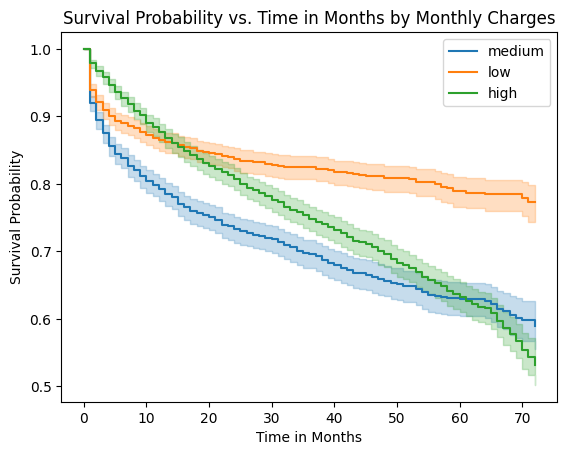

In [4]:
customer_data['Monthly Charges_bin'] = pd.qcut(
    customer_data['Monthly Charge'],
    q = 3,
    labels = ['low', 'medium', 'high'])

for monthly_charges in customer_data['Monthly Charges_bin'].unique():
    mask = customer_data['Monthly Charges_bin'] == monthly_charges
    kmf.fit(durations = T[mask],
            event_observed = E[mask],
            label = monthly_charges)

    kmf.plot_survival_function()
    plt.xlabel('Time in Months')
    plt.ylabel('Survival Probability')
    plt.title('Survival Probability vs. Time in Months by Monthly Charges')

These survival curves, while quite distinct, run closer together than for contract type. To ensure that there truly is a significant difference in survival probability over time among the three monthly charge bins here, we run a k-sample log rank test below.

In [5]:
from lifelines.statistics import multivariate_logrank_test

results = multivariate_logrank_test(
    T,
    customer_data['Monthly Charges_bin'],
    E)

results.print_summary()

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          89.40 <0.005     64.49

With p < 0.005 we are able to **reject** the null hypothesis that the survival curves have no significant difference

**Customer survival differs significantly across monthly charge tiers**

Note that as we only looked at monthly charges here (univariate), we cannot say whether this effect will persist after introducing all our other variables. We'll see below that once Contract is introduced, Monthly Charges become a much less significant predictor for churn hazard

*Remember that we did mention contract type being a churn blocker -- we'll ignore this for now for the sake of our CoxPH analysis below, but we'll come to it later*

## Cox Proportional Hazards Model

In [6]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()

# We build a smaller focus dataset first based on columns we already know strongly affect churn
cph_data = customer_data[['Tenure in Months', 'Customer Status', 'Monthly Charge', 'Contract']]
# CoxPH cannot work with string, so we encode Contract below
cph_data = pd.get_dummies(cph_data, columns=['Contract'], drop_first=True)

cph_data['Event'] = (cph_data['Customer Status'] == 'Churned').astype(int)
cph_data = cph_data.drop(columns=['Customer Status'], axis=1)

cph.fit(cph_data,
        duration_col = 'Tenure in Months',
        event_col = 'Event')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'Tenure in Months'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -14170.35
         time fit was run = 2025-12-26 16:20:01 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Monthly Charge     0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Contract_One Year -2.35      0.10      0.08           -2.52           -2.19                0.08                0.11
Contract_Two Year -4.42      0.01      0.16           -4.73           -4.11                0.01                0.02

                   cmp to      z      p  -log2(p)
covariate                                        
Monthly Charge       0.00   1.48   0.14      2.85
Contract_One Year    0.00 -28.06 <0.005    572.97
Contract_Two Year    0.00 -28.04 <0.005    572.20
---
Concordance = 0.78
Partial AIC = 28346.69
log-likelihood ratio test = 2968.83 on 3 df
-log2(p) of ll-ratio test = inf

Our results are stating that:
* **Monthly charges**
    * exp(coef) = 1 : No effect to churn
    * p > 0.005 : no statistical significant effect
        * Now that we've introduced Contract as well, monthly charge actually becomes insignificant <br><br>
* **One Year**
    * exp(coef) = 0.10 : 90% less likely to churn **compared to monthly contract customers**
    * P < 0.005 : statistically significant <br><br>
* **Two Year**
    * exp(coef) = 0.01 : 99% less likely to churn **compared to monthly contract customers**
    * P < 0.005 : statistically significant  <br><br>
* **Concordance** = 0.78 : This model correctly ranks churn timing 78% of the time

In [7]:
# Suggested step to sense check if any variables are non-proportional
cph.check_assumptions(cph_data, p_value_threshold=0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
         test_name = proportional_hazard_test

---
                        test_statistic      p  -log2(p)
Contract_One Year km            103.35 <0.005     78.24
                  rank           82.46 <0.005     63.01
Contract_Two Year km             44.98 <0.005     35.55
                  rank           28.79 <0.005     23.56
Monthly Charge    km             68.65 <0.005     52.92
                  rank           74.69 <0.005     57.34



1. Variable 'Monthly Charge' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Monthly Charge' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Monthly Charge' using pd.cut, and then specify it in
`strata=['Monthly Charge', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'Contract_One Year' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['Contract_One Year', ...]`
in the call in `.fit`. See documentation in link [E] below.

3. Variable 'Contract_Two Year' failed the non-proportional test: p-value is <5e-05.

[]

### Stratified Cox Proportional Hazards Model

Since Contract is a structural barrier to churn and not indicative of customer behaviour, it is recommended to stratify our data by contract type. This keeps one model but allows for differing baseline hazards by Contract type.

In [8]:
cph_data_strat = customer_data[['Tenure in Months', 'Age', 'Number of Referrals', 'Number of Dependents', 'Customer Status', 'Monthly Charge', 'Contract']]
cph_data_strat['Event'] = (cph_data_strat['Customer Status'] == 'Churned').astype(int)
cph_data_strat = cph_data_strat.drop(columns=['Customer Status'], axis=1)

cph.fit(cph_data_strat,
        duration_col = 'Tenure in Months',
        event_col = 'Event',
        strata=['Contract'])

cph.print_summary()

C:\Users\atyap\AppData\Local\Temp\ipykernel_16200\4111697019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cph_data_strat['Event'] = (cph_data_strat['Customer Status'] == 'Churned').astype(int)


<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'Tenure in Months'
                event col = 'Event'
                   strata = Contract
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13242.82
         time fit was run = 2025-12-26 16:20:02 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
Age                   0.01      1.01      0.00            0.01            0.01                1.01                1.01
Number of Referrals  -0.29      0.74      0.02           -0.33           -0.26                0.72                0.77
Number of Dependents -0.40      0.67      0.05           -0.50           -0.31                0.61                0.74
Monthly Charge        0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                      cmp to      z      p  -log2(p)
covariate                                           
Age                     0.00   5.63 <0.005     25.69
Number of Referrals     0.00 -15.64 <0.005    180.69
Number of Dependents    0.00  -8.13 <0.005     51.01
Monthly Charge          0.00   0.01   1.00      0.01
---
Concordance = 0.63
Partial AIC = 26493.64
log-likelihood ratio test = 716.86 on 4 df
-log2(p) of ll-ratio test = 508.61

Our results are stating that, within each contract type:
* **Age**
    * exp(coef) = 1.01 : Very minimal effect to churn (1% increase in hazard per year aged)
    * p < 0.005 : statistically significant <br><br>
* **Number of Referrals**
    * exp(coef) = 0.74 : 26% less likely to churn per referral
    * P < 0.005 : statistically significant <br><br>
* **Number of Dependents**
    * exp(coef) = 0.67 : 33% less likely to churn per dependent
    * P < 0.005 : statistically significant  <br><br>
* **Monthly Charge**
    * exp(coef) = 1.00 : No effect to churn
    * P > 0.005 : not statistically significant  <br><br>
* **Concordance** = 0.63 : This model correctly ranks churn timing 63% of the time
    * This is decreased compared to 78% earlier as we've now made our assumptions more fair with the removal of Contract as a predictor

In [9]:
# Checking the amount of entries per Contract type
cph_data_strat['Contract'].value_counts()

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64

#### Risk Scores

In [10]:
risk_scores = cph.predict_log_partial_hazard(cph_data_strat)
risk_scores
# higher score = higher churn risk (for comparing customers within the same stratum)

0       0.101269
1       0.760592
2       0.791966
3       0.714178
4       0.100969
          ...   
7038    0.559332
7039    0.419560
7040    0.574813
7041   -0.907577
7042    0.388431
Length: 7043, dtype: float64

**Calculating expected remaining tenure**

In [11]:
# Calculating baseline remaining tenure for month-to-month contract customers
baseline_survival = cph.baseline_survival_

S0 = baseline_survival['Month-to-Month']
t = S0.index.values
baseline_auc = np.trapezoid(S0.values, t)

# Calculating adjusted remaining tenure for month-to-month contract customers
HR_from_referral = (cph.summary).loc['Number of Referrals', 'exp(coef)'] # Pull hazard ratio value

S_adjusted = S0 ** HR_from_referral     # exponential operator : **
adjusted_auc = np.trapezoid(S_adjusted, t)

# Tenure lift for portion of cohort affected
uptake = 0.3 # For example's sake, assuming 30% of cohort affected by treatment
tenure_lift = (adjusted_auc - baseline_auc)
avg_tenure_lift_monthly_cohort = tenure_lift * uptake

# Calculations across cohort size and overall customer base size
cohort_size = (cph_data_strat['Contract']=='Month-to-Month').sum()
cohort_share = cohort_size / len(cph_data_strat)

uptake_adjusted_for_base = cohort_share * uptake
tenure_lift_overall = uptake_adjusted_for_base * tenure_lift

# Revenue uplift calculations
avg_monthly_charges = cph_data_strat[cph_data_strat['Contract']=='Month-to-Month']['Monthly Charge'].mean()
revenue_uplift_overall = avg_monthly_charges * avg_tenure_lift_monthly_cohort * cohort_size

print(f'Portfolio size: {len(cph_data_strat)}')
print(f'Month-to-month cohort size: {cohort_size}\n')

print(f'Expected remaining baseline tenure for month-to-month customers: {baseline_auc:.2f} months')
print(f'Expected remaining adjusted tenure for month-to-month customers: {adjusted_auc:.2f} months\n')

print(f'Avg tenure lift per treated customer: {tenure_lift:.2f} months')
print(f'Avg tenure lift per customer across month-to-month cohort: {avg_tenure_lift_monthly_cohort:.2f} months')
print(f'Avg tenure lift per customer across portfolio: {tenure_lift_overall:.2f} months\n')

print(f'Current average monthly charges for month-to-month customers: ${avg_monthly_charges:.2f}')
print(f'Overall revenue uplift: ${revenue_uplift_overall:,.2f}')
print(f'Revenue uplift per customer in portfolio: ${revenue_uplift_overall/len(cph_data_strat):,.2f}')

Portfolio size: 7043
Month-to-month cohort size: 3610

Expected remaining baseline tenure for month-to-month customers: 41.56 months
Expected remaining adjusted tenure for month-to-month customers: 47.11 months

Avg tenure lift per treated customer: 5.54 months
Avg tenure lift per customer across month-to-month cohort: 1.66 months
Avg tenure lift per customer across portfolio: 0.85 months

Current average monthly charges for month-to-month customers: $64.39
Overall revenue uplift: $386,595.04
Revenue uplift per customer in portfolio: $54.89


**Bonus: What if I wanted to know the remaining tenure for month-to-month customers that are currently at 20 months of tenure?**

In [12]:
t0 = 20
S_t0 = S0.loc[t0]

remaining_tenure = np.trapezoid(
    S0[S0.index >= t0].values / S_t0,
    S0[S0.index >= t0].index.values
)

print(f'Month-to-month customers currently at 20 months tenure will have an average remaining tenure of: {remaining_tenure:.0f} months')

Month-to-month customers currently at 20 months tenure will have an average remaining tenure of: 36 months


**Why does this differ from our baseline tenure of 41.6 months?** <br>
Our baseline tenure is analysed from t0 = 0 months i.e., new month-to-month customers. As a customer lives through their tenure, their survivorship expectation changes as well. With our 20-month tenure customers, as they have already survived up to 20 months, we expect them to be stickier compared to customers at, say, 2 months tenure.